# SIH26059 — Adaptive Mission-Aware Antarctic Navigation
## Person 2 + Person 3 + Person 5 real-data integration

This notebook integrates the **provided team inputs** instead of the earlier dummy data:

- **Person 2 / CV:** georeferenced iceberg detections with `iceberg_id`, latitude, longitude, `area_km2`, confidence, and scene timestamp.
- **Person 3 / trajectory:** the supplied `trajectory_predictions_person4.csv` contract with 6h/12h/24h/48h predictions and uncertainty where available.
- **Person 5 / sea ice:** the supplied Antarctic sea-ice concentration NetCDF product from the Athena demo data.

### Important integration audit
The supplied Person 2 CV IDs (`IB_001`, …) do **not** overlap with the Person 3 trajectory IDs, and the CV scene timestamp is not temporally aligned with the trajectory prediction dates. Therefore this notebook **does not fabricate an ID match or pretend the streams are live-synchronized**.

For the reproducible demo, the CV detections are used as the current spatial hazard layer. A real Person 3 trajectory record is then introduced as an incoming update in the adaptive-replanning stage. This demonstrates the intended **CV → trajectory → risk → routing** architecture without inventing correspondence between the two teams' identifiers.

Person 3's handoff also states that missing `uncertainty_km` for 6h/12h must not be interpreted as zero; this notebook follows that rule.


In [1]:
# SETUP
!pip install -q geopandas shapely pyproj pandas numpy matplotlib

import os
import json
import math
import heapq
import itertools
import gzip
import base64
from io import StringIO

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point, Polygon
from matplotlib.patches import Circle

print("Setup complete")


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 785, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 720, in _warm_feature_flows
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 704, in _warm_collaboration_flows
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/generated/interface/models.py", line 32317, in hydrate_crdt_from_proto
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/remote.py", line 749, in __call__
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/client.py", line 150, in call
artifact_tool.rpc.client.

Setup complete


In [2]:
# CONFIGURATION
CONFIG = {
    # Domain chosen to contain the supplied CV detections,
    # the spatially relevant trajectory predictions, and the SIC product.
    "grid_step_deg": 0.05,
    "min_lat": -67.5,
    "max_lat": -64.5,
    "min_lon": 131.5,
    "max_lon": 139.0,

    # Safety buffers are configurable prototype assumptions.
    "iceberg_buffer_km": 9.26,       # 5 nautical miles
    "trajectory_buffer_km": 5.0,
    "confidence_buffer_km": 10.0,    # extra conservatism for low CV confidence
    "uncertainty_multiplier": 1.0,

    # Sea-ice hard constraint.
    "max_ice_concentration": 0.60,
    "sea_ice_hard_radius_km": 20.0,
    "sea_ice_knn": 8,
    "sea_ice_idw_power": 2.0,

    # Continuous risk weights.
    "risk_weights": {
        "iceberg": 0.35,
        "trajectory": 0.25,
        "sea_ice": 0.25,
        "uncertainty": 0.10,
        "quality": 0.05,
    },

    "route_risk_weight": 10.0,
    "speed_knots": 12.0,

    # Mission-level constraints.
    "mission_max_eta_hours": 60.0,
    "mission_distance_budget_km": 1000.0,
    "optional_waypoint_priority_bonus": 0.01,
}

print(CONFIG)


{'grid_step_deg': 0.05, 'min_lat': -67.5, 'max_lat': -64.5, 'min_lon': 131.5, 'max_lon': 139.0, 'iceberg_buffer_km': 9.26, 'trajectory_buffer_km': 5.0, 'confidence_buffer_km': 10.0, 'uncertainty_multiplier': 1.0, 'max_ice_concentration': 0.6, 'sea_ice_hard_radius_km': 20.0, 'sea_ice_knn': 8, 'sea_ice_idw_power': 2.0, 'risk_weights': {'iceberg': 0.35, 'trajectory': 0.25, 'sea_ice': 0.25, 'uncertainty': 0.1, 'quality': 0.05}, 'route_risk_weight': 10.0, 'speed_knots': 12.0, 'mission_max_eta_hours': 60.0, 'mission_distance_budget_km': 1000.0, 'optional_waypoint_priority_bonus': 0.01}


In [3]:
# REAL TEAM INPUTS — EMBEDDED FROM PROVIDED FILES

# -------------------------
# Person 2: CV detections
# -------------------------
CV_TIMESTAMP = "2021-03-10T10:48:42"
cv_records = [{"iceberg_id":"IB_001","latitude":-65.98366,"longitude":136.123995,"area_km2":15.4544,"confidence":0.9561,"pixel_count":9659},{"iceberg_id":"IB_002","latitude":-66.024175,"longitude":136.039424,"area_km2":9.0816,"confidence":0.9071,"pixel_count":5676},{"iceberg_id":"IB_003","latitude":-66.089311,"longitude":136.205681,"area_km2":2.9168,"confidence":0.9186,"pixel_count":1823},{"iceberg_id":"IB_004","latitude":-66.04945,"longitude":136.193685,"area_km2":2.7536,"confidence":0.9071,"pixel_count":1721},{"iceberg_id":"IB_005","latitude":-65.995772,"longitude":136.274136,"area_km2":2.6144,"confidence":0.963,"pixel_count":1634},{"iceberg_id":"IB_006","latitude":-65.976871,"longitude":135.936047,"area_km2":2.3968,"confidence":0.9709,"pixel_count":1498},{"iceberg_id":"IB_007","latitude":-65.741429,"longitude":136.252681,"area_km2":2.3152,"confidence":0.9835,"pixel_count":1447},{"iceberg_id":"IB_008","latitude":-65.964036,"longitude":135.980254,"area_km2":2.2224,"confidence":0.9631,"pixel_count":1389},{"iceberg_id":"IB_009","latitude":-66.092788,"longitude":136.119739,"area_km2":2.136,"confidence":0.927,"pixel_count":1335},{"iceberg_id":"IB_010","latitude":-66.04658,"longitude":136.335952,"area_km2":1.9136,"confidence":0.9382,"pixel_count":1196},{"iceberg_id":"IB_011","latitude":-65.992838,"longitude":135.947914,"area_km2":1.872,"confidence":0.9645,"pixel_count":1170},{"iceberg_id":"IB_012","latitude":-66.023673,"longitude":135.91156,"area_km2":1.8624,"confidence":0.976,"pixel_count":1164},{"iceberg_id":"IB_013","latitude":-65.82485,"longitude":135.465822,"area_km2":1.8336,"confidence":0.9603,"pixel_count":1146},{"iceberg_id":"IB_014","latitude":-66.070611,"longitude":136.20677,"area_km2":1.6288,"confidence":0.9219,"pixel_count":1018},{"iceberg_id":"IB_015","latitude":-65.981124,"longitude":136.030206,"area_km2":1.5744,"confidence":0.975,"pixel_count":984},{"iceberg_id":"IB_016","latitude":-66.034332,"longitude":136.145167,"area_km2":1.5056,"confidence":0.8766,"pixel_count":941},{"iceberg_id":"IB_017","latitude":-65.994025,"longitude":136.237151,"area_km2":1.4816,"confidence":0.9345,"pixel_count":926},{"iceberg_id":"IB_018","latitude":-65.854636,"longitude":135.455715,"area_km2":1.4048,"confidence":0.9733,"pixel_count":878},{"iceberg_id":"IB_019","latitude":-66.033741,"longitude":136.170737,"area_km2":1.3408,"confidence":0.9442,"pixel_count":838},{"iceberg_id":"IB_020","latitude":-65.85581,"longitude":136.322501,"area_km2":1.3392,"confidence":0.9436,"pixel_count":837},{"iceberg_id":"IB_021","latitude":-65.737498,"longitude":136.154333,"area_km2":1.2368,"confidence":0.9689,"pixel_count":773},{"iceberg_id":"IB_022","latitude":-65.731642,"longitude":136.300137,"area_km2":1.136,"confidence":0.9422,"pixel_count":710},{"iceberg_id":"IB_023","latitude":-65.950339,"longitude":136.47053,"area_km2":1.12,"confidence":0.9659,"pixel_count":700},{"iceberg_id":"IB_024","latitude":-66.019281,"longitude":135.96592,"area_km2":1.072,"confidence":0.9646,"pixel_count":670},{"iceberg_id":"IB_025","latitude":-65.999579,"longitude":135.914124,"area_km2":1.04,"confidence":0.9541,"pixel_count":650},{"iceberg_id":"IB_026","latitude":-65.972717,"longitude":136.096165,"area_km2":1.0032,"confidence":0.9706,"pixel_count":627},{"iceberg_id":"IB_027","latitude":-66.110721,"longitude":136.138607,"area_km2":0.9776,"confidence":0.9332,"pixel_count":611},{"iceberg_id":"IB_028","latitude":-66.003676,"longitude":135.961919,"area_km2":0.9776,"confidence":0.957,"pixel_count":611},{"iceberg_id":"IB_029","latitude":-65.832701,"longitude":136.69341,"area_km2":0.944,"confidence":0.9724,"pixel_count":590},{"iceberg_id":"IB_030","latitude":-66.041713,"longitude":136.294108,"area_km2":0.928,"confidence":0.8334,"pixel_count":580},{"iceberg_id":"IB_031","latitude":-65.948836,"longitude":136.190137,"area_km2":0.9216,"confidence":0.9582,"pixel_count":576},{"iceberg_id":"IB_032","latitude":-65.974116,"longitude":136.066392,"area_km2":0.9056,"confidence":0.9659,"pixel_count":566},{"iceberg_id":"IB_033","latitude":-66.024662,"longitude":136.212484,"area_km2":0.8384,"confidence":0.9245,"pixel_count":524},{"iceberg_id":"IB_034","latitude":-65.842139,"longitude":135.461558,"area_km2":0.8272,"confidence":0.9693,"pixel_count":517},{"iceberg_id":"IB_035","latitude":-66.084824,"longitude":136.100512,"area_km2":0.8128,"confidence":0.9074,"pixel_count":508},{"iceberg_id":"IB_036","latitude":-65.805303,"longitude":136.541478,"area_km2":0.7744,"confidence":0.929,"pixel_count":484},{"iceberg_id":"IB_037","latitude":-65.839047,"longitude":135.988522,"area_km2":0.7424,"confidence":0.742,"pixel_count":464},{"iceberg_id":"IB_038","latitude":-65.851453,"longitude":135.908395,"area_km2":0.7312,"confidence":0.7323,"pixel_count":457},{"iceberg_id":"IB_039","latitude":-65.801268,"longitude":136.183253,"area_km2":0.72,"confidence":0.9613,"pixel_count":450},{"iceberg_id":"IB_040","latitude":-65.840305,"longitude":135.898125,"area_km2":0.7104,"confidence":0.6576,"pixel_count":444},{"iceberg_id":"IB_041","latitude":-65.829445,"longitude":136.059002,"area_km2":0.7072,"confidence":0.6279,"pixel_count":442},{"iceberg_id":"IB_042","latitude":-66.077819,"longitude":136.191327,"area_km2":0.6848,"confidence":0.9293,"pixel_count":428},{"iceberg_id":"IB_043","latitude":-65.990224,"longitude":136.14777,"area_km2":0.6816,"confidence":0.6895,"pixel_count":426},{"iceberg_id":"IB_044","latitude":-66.056579,"longitude":136.168587,"area_km2":0.6512,"confidence":0.8915,"pixel_count":407},{"iceberg_id":"IB_045","latitude":-66.085565,"longitude":136.164588,"area_km2":0.6416,"confidence":0.934,"pixel_count":401},{"iceberg_id":"IB_046","latitude":-65.800003,"longitude":135.560179,"area_km2":0.6096,"confidence":0.9504,"pixel_count":381},{"iceberg_id":"IB_047","latitude":-66.02332,"longitude":136.188405,"area_km2":0.512,"confidence":0.923,"pixel_count":320},{"iceberg_id":"IB_048","latitude":-65.887552,"longitude":136.366741,"area_km2":0.4912,"confidence":0.9511,"pixel_count":307},{"iceberg_id":"IB_049","latitude":-66.024063,"longitude":136.235802,"area_km2":0.4784,"confidence":0.8998,"pixel_count":299},{"iceberg_id":"IB_050","latitude":-65.826388,"longitude":135.758118,"area_km2":0.4704,"confidence":0.7477,"pixel_count":294},{"iceberg_id":"IB_051","latitude":-65.827487,"longitude":135.818739,"area_km2":0.464,"confidence":0.8906,"pixel_count":290},{"iceberg_id":"IB_052","latitude":-65.764501,"longitude":136.203959,"area_km2":0.4592,"confidence":0.9523,"pixel_count":287},{"iceberg_id":"IB_053","latitude":-65.75042,"longitude":135.829049,"area_km2":0.432,"confidence":0.9477,"pixel_count":270},{"iceberg_id":"IB_054","latitude":-65.723648,"longitude":136.289294,"area_km2":0.432,"confidence":0.9603,"pixel_count":270},{"iceberg_id":"IB_055","latitude":-65.925633,"longitude":136.425375,"area_km2":0.416,"confidence":0.9486,"pixel_count":260},{"iceberg_id":"IB_056","latitude":-66.003383,"longitude":136.227604,"area_km2":0.3936,"confidence":0.9134,"pixel_count":246},{"iceberg_id":"IB_057","latitude":-65.762035,"longitude":135.724813,"area_km2":0.3824,"confidence":0.9512,"pixel_count":239},{"iceberg_id":"IB_058","latitude":-66.008603,"longitude":136.243371,"area_km2":0.3728,"confidence":0.882,"pixel_count":233},{"iceberg_id":"IB_059","latitude":-65.815915,"longitude":135.77862,"area_km2":0.3696,"confidence":0.9159,"pixel_count":231},{"iceberg_id":"IB_060","latitude":-65.919662,"longitude":136.444374,"area_km2":0.3664,"confidence":0.9448,"pixel_count":229},{"iceberg_id":"IB_061","latitude":-65.909083,"longitude":136.493339,"area_km2":0.3632,"confidence":0.9435,"pixel_count":227},{"iceberg_id":"IB_062","latitude":-65.690458,"longitude":135.891153,"area_km2":0.344,"confidence":0.9235,"pixel_count":215},{"iceberg_id":"IB_063","latitude":-65.99921,"longitude":136.513956,"area_km2":0.3424,"confidence":0.9458,"pixel_count":214},{"iceberg_id":"IB_064","latitude":-65.862986,"longitude":136.223489,"area_km2":0.3424,"confidence":0.9539,"pixel_count":214},{"iceberg_id":"IB_065","latitude":-65.802387,"longitude":136.394055,"area_km2":0.3408,"confidence":0.9296,"pixel_count":213},{"iceberg_id":"IB_066","latitude":-65.821461,"longitude":136.421402,"area_km2":0.2992,"confidence":0.6015,"pixel_count":187},{"iceberg_id":"IB_067","latitude":-66.0377,"longitude":136.2023,"area_km2":0.2912,"confidence":0.9315,"pixel_count":182},{"iceberg_id":"IB_068","latitude":-65.706962,"longitude":135.723833,"area_km2":0.2912,"confidence":0.8994,"pixel_count":182},{"iceberg_id":"IB_069","latitude":-65.860766,"longitude":136.574226,"area_km2":0.2864,"confidence":0.9475,"pixel_count":179},{"iceberg_id":"IB_070","latitude":-65.990875,"longitude":136.514131,"area_km2":0.2848,"confidence":0.9543,"pixel_count":178},{"iceberg_id":"IB_071","latitude":-66.011781,"longitude":136.203865,"area_km2":0.2832,"confidence":0.7473,"pixel_count":177},{"iceberg_id":"IB_072","latitude":-66.005225,"longitude":136.500788,"area_km2":0.2832,"confidence":0.9483,"pixel_count":177},{"iceberg_id":"IB_073","latitude":-65.871801,"longitude":136.662183,"area_km2":0.2832,"confidence":0.9425,"pixel_count":177},{"iceberg_id":"IB_074","latitude":-66.101941,"longitude":136.089459,"area_km2":0.28,"confidence":0.7437,"pixel_count":175},{"iceberg_id":"IB_075","latitude":-65.689569,"longitude":135.832124,"area_km2":0.2752,"confidence":0.9406,"pixel_count":172},{"iceberg_id":"IB_076","latitude":-65.874779,"longitude":136.587334,"area_km2":0.272,"confidence":0.8906,"pixel_count":170},{"iceberg_id":"IB_077","latitude":-65.74809,"longitude":135.678176,"area_km2":0.2688,"confidence":0.896,"pixel_count":168},{"iceberg_id":"IB_078","latitude":-65.749925,"longitude":135.711111,"area_km2":0.2592,"confidence":0.9316,"pixel_count":162},{"iceberg_id":"IB_079","latitude":-65.814042,"longitude":135.854968,"area_km2":0.248,"confidence":0.9157,"pixel_count":155},{"iceberg_id":"IB_080","latitude":-65.961136,"longitude":136.188209,"area_km2":0.2368,"confidence":0.8912,"pixel_count":148},{"iceberg_id":"IB_081","latitude":-66.026547,"longitude":136.446031,"area_km2":0.2368,"confidence":0.8825,"pixel_count":148},{"iceberg_id":"IB_082","latitude":-65.746551,"longitude":135.656381,"area_km2":0.2336,"confidence":0.9113,"pixel_count":146},{"iceberg_id":"IB_083","latitude":-65.877841,"longitude":136.471534,"area_km2":0.2304,"confidence":0.9446,"pixel_count":144},{"iceberg_id":"IB_084","latitude":-65.940429,"longitude":135.853604,"area_km2":0.2096,"confidence":0.9126,"pixel_count":131},{"iceberg_id":"IB_085","latitude":-65.896529,"longitude":136.230522,"area_km2":0.2064,"confidence":0.932,"pixel_count":129},{"iceberg_id":"IB_086","latitude":-66.095389,"longitude":136.170732,"area_km2":0.1968,"confidence":0.9032,"pixel_count":123},{"iceberg_id":"IB_087","latitude":-65.862049,"longitude":136.166963,"area_km2":0.1952,"confidence":0.8749,"pixel_count":122},{"iceberg_id":"IB_088","latitude":-65.94494,"longitude":135.835443,"area_km2":0.1936,"confidence":0.8856,"pixel_count":121},{"iceberg_id":"IB_089","latitude":-65.849762,"longitude":136.263159,"area_km2":0.1936,"confidence":0.9392,"pixel_count":121},{"iceberg_id":"IB_090","latitude":-65.955455,"longitude":136.453212,"area_km2":0.192,"confidence":0.925,"pixel_count":120},{"iceberg_id":"IB_091","latitude":-65.717683,"longitude":136.077219,"area_km2":0.1824,"confidence":0.5029,"pixel_count":114},{"iceberg_id":"IB_092","latitude":-65.819787,"longitude":136.478259,"area_km2":0.1792,"confidence":0.7921,"pixel_count":112},{"iceberg_id":"IB_093","latitude":-65.687731,"longitude":136.029133,"area_km2":0.168,"confidence":0.908,"pixel_count":105},{"iceberg_id":"IB_094","latitude":-65.698032,"longitude":136.286165,"area_km2":0.168,"confidence":0.8383,"pixel_count":105},{"iceberg_id":"IB_095","latitude":-65.823965,"longitude":135.662037,"area_km2":0.1648,"confidence":0.7757,"pixel_count":103},{"iceberg_id":"IB_096","latitude":-65.906496,"longitude":136.448163,"area_km2":0.1632,"confidence":0.8993,"pixel_count":102},{"iceberg_id":"IB_097","latitude":-65.819587,"longitude":136.436629,"area_km2":0.1472,"confidence":0.6492,"pixel_count":92},{"iceberg_id":"IB_098","latitude":-65.831925,"longitude":136.000021,"area_km2":0.1344,"confidence":0.7726,"pixel_count":84},{"iceberg_id":"IB_099","latitude":-65.832908,"longitude":135.799398,"area_km2":0.1328,"confidence":0.8957,"pixel_count":83},{"iceberg_id":"IB_100","latitude":-65.843784,"longitude":136.545754,"area_km2":0.1328,"confidence":0.7335,"pixel_count":83},{"iceberg_id":"IB_101","latitude":-65.894685,"longitude":135.712341,"area_km2":0.1312,"confidence":0.6011,"pixel_count":82},{"iceberg_id":"IB_102","latitude":-65.716583,"longitude":135.713054,"area_km2":0.128,"confidence":0.8714,"pixel_count":80},{"iceberg_id":"IB_103","latitude":-66.003456,"longitude":136.490205,"area_km2":0.128,"confidence":0.8834,"pixel_count":80},{"iceberg_id":"IB_104","latitude":-65.809015,"longitude":136.449251,"area_km2":0.1216,"confidence":0.8573,"pixel_count":76},{"iceberg_id":"IB_105","latitude":-66.016114,"longitude":136.262598,"area_km2":0.12,"confidence":0.8165,"pixel_count":75},{"iceberg_id":"IB_106","latitude":-65.686892,"longitude":136.00756,"area_km2":0.1184,"confidence":0.8913,"pixel_count":74},{"iceberg_id":"IB_107","latitude":-65.714169,"longitude":136.256746,"area_km2":0.1184,"confidence":0.8374,"pixel_count":74},{"iceberg_id":"IB_108","latitude":-65.945655,"longitude":136.445565,"area_km2":0.1168,"confidence":0.9218,"pixel_count":73},{"iceberg_id":"IB_109","latitude":-65.747239,"longitude":135.735039,"area_km2":0.1152,"confidence":0.9097,"pixel_count":72},{"iceberg_id":"IB_110","latitude":-65.746871,"longitude":135.756623,"area_km2":0.1152,"confidence":0.8006,"pixel_count":72},{"iceberg_id":"IB_111","latitude":-65.698129,"longitude":135.737763,"area_km2":0.1024,"confidence":0.8572,"pixel_count":64},{"iceberg_id":"IB_112","latitude":-66.03591,"longitude":136.256169,"area_km2":0.0992,"confidence":0.7953,"pixel_count":62},{"iceberg_id":"IB_113","latitude":-66.009015,"longitude":136.483434,"area_km2":0.0992,"confidence":0.9039,"pixel_count":62},{"iceberg_id":"IB_114","latitude":-65.874197,"longitude":135.835686,"area_km2":0.0976,"confidence":0.5877,"pixel_count":61},{"iceberg_id":"IB_115","latitude":-66.094244,"longitude":136.146653,"area_km2":0.096,"confidence":0.8793,"pixel_count":60},{"iceberg_id":"IB_116","latitude":-65.868021,"longitude":136.023324,"area_km2":0.0944,"confidence":0.5241,"pixel_count":59},{"iceberg_id":"IB_117","latitude":-65.816892,"longitude":135.841022,"area_km2":0.0896,"confidence":0.7709,"pixel_count":56},{"iceberg_id":"IB_118","latitude":-65.894489,"longitude":136.374278,"area_km2":0.0832,"confidence":0.8772,"pixel_count":52},{"iceberg_id":"IB_119","latitude":-65.94254,"longitude":136.458622,"area_km2":0.08,"confidence":0.8962,"pixel_count":50},{"iceberg_id":"IB_120","latitude":-66.034353,"longitude":136.10323,"area_km2":0.0784,"confidence":0.6345,"pixel_count":49},{"iceberg_id":"IB_121","latitude":-65.713754,"longitude":136.141984,"area_km2":0.0768,"confidence":0.7791,"pixel_count":48},{"iceberg_id":"IB_122","latitude":-65.689175,"longitude":136.149102,"area_km2":0.0752,"confidence":0.7429,"pixel_count":47},{"iceberg_id":"IB_123","latitude":-66.078338,"longitude":136.003159,"area_km2":0.0736,"confidence":0.8045,"pixel_count":46},{"iceberg_id":"IB_124","latitude":-65.955316,"longitude":135.851756,"area_km2":0.0736,"confidence":0.8063,"pixel_count":46},{"iceberg_id":"IB_125","latitude":-66.036753,"longitude":136.217132,"area_km2":0.072,"confidence":0.8639,"pixel_count":45},{"iceberg_id":"IB_126","latitude":-66.008775,"longitude":136.311981,"area_km2":0.072,"confidence":0.8729,"pixel_count":45},{"iceberg_id":"IB_127","latitude":-66.077821,"longitude":136.238207,"area_km2":0.0704,"confidence":0.777,"pixel_count":44},{"iceberg_id":"IB_128","latitude":-65.870021,"longitude":136.045404,"area_km2":0.0704,"confidence":0.6999,"pixel_count":44},{"iceberg_id":"IB_129","latitude":-65.824303,"longitude":136.064146,"area_km2":0.0704,"confidence":0.512,"pixel_count":44},{"iceberg_id":"IB_130","latitude":-65.976474,"longitude":136.486143,"area_km2":0.0704,"confidence":0.8928,"pixel_count":44},{"iceberg_id":"IB_131","latitude":-65.684705,"longitude":136.050052,"area_km2":0.0704,"confidence":0.8248,"pixel_count":44},{"iceberg_id":"IB_132","latitude":-65.839596,"longitude":136.052338,"area_km2":0.0688,"confidence":0.6204,"pixel_count":43},{"iceberg_id":"IB_133","latitude":-66.054399,"longitude":136.228594,"area_km2":0.0672,"confidence":0.6954,"pixel_count":42},{"iceberg_id":"IB_134","latitude":-65.819842,"longitude":135.803297,"area_km2":0.0672,"confidence":0.8107,"pixel_count":42},{"iceberg_id":"IB_135","latitude":-66.134945,"longitude":136.171976,"area_km2":0.0656,"confidence":0.8008,"pixel_count":41},{"iceberg_id":"IB_136","latitude":-65.952269,"longitude":136.075587,"area_km2":0.0656,"confidence":0.9167,"pixel_count":41},{"iceberg_id":"IB_137","latitude":-65.77828,"longitude":135.794759,"area_km2":0.0656,"confidence":0.8931,"pixel_count":41},{"iceberg_id":"IB_138","latitude":-65.837158,"longitude":135.753569,"area_km2":0.064,"confidence":0.8072,"pixel_count":40},{"iceberg_id":"IB_139","latitude":-65.862927,"longitude":135.9351,"area_km2":0.064,"confidence":0.5497,"pixel_count":40},{"iceberg_id":"IB_140","latitude":-66.035612,"longitude":136.290196,"area_km2":0.0624,"confidence":0.841,"pixel_count":39},{"iceberg_id":"IB_141","latitude":-65.954625,"longitude":136.205926,"area_km2":0.0624,"confidence":0.8594,"pixel_count":39},{"iceberg_id":"IB_142","latitude":-66.014292,"longitude":136.318102,"area_km2":0.0608,"confidence":0.8784,"pixel_count":38},{"iceberg_id":"IB_143","latitude":-65.938804,"longitude":136.076022,"area_km2":0.0592,"confidence":0.7443,"pixel_count":37},{"iceberg_id":"IB_144","latitude":-65.98375,"longitude":136.299208,"area_km2":0.0592,"confidence":0.9064,"pixel_count":37},{"iceberg_id":"IB_145","latitude":-65.871785,"longitude":135.821342,"area_km2":0.0576,"confidence":0.6233,"pixel_count":36},{"iceberg_id":"IB_146","latitude":-65.956622,"longitude":136.21841,"area_km2":0.0576,"confidence":0.8847,"pixel_count":36},{"iceberg_id":"IB_147","latitude":-66.086498,"longitude":136.231989,"area_km2":0.0544,"confidence":0.7937,"pixel_count":34},{"iceberg_id":"IB_148","latitude":-65.882481,"longitude":136.235543,"area_km2":0.0544,"confidence":0.9054,"pixel_count":34},{"iceberg_id":"IB_149","latitude":-66.114069,"longitude":136.095887,"area_km2":0.0496,"confidence":0.7821,"pixel_count":31},{"iceberg_id":"IB_150","latitude":-65.976929,"longitude":136.259494,"area_km2":0.0496,"confidence":0.8354,"pixel_count":31},{"iceberg_id":"IB_151","latitude":-65.832975,"longitude":135.935392,"area_km2":0.0496,"confidence":0.6686,"pixel_count":31},{"iceberg_id":"IB_152","latitude":-65.972984,"longitude":136.461634,"area_km2":0.0496,"confidence":0.8386,"pixel_count":31},{"iceberg_id":"IB_153","latitude":-65.702863,"longitude":136.167553,"area_km2":0.0496,"confidence":0.7834,"pixel_count":31},{"iceberg_id":"IB_154","latitude":-65.98934,"longitude":136.214823,"area_km2":0.048,"confidence":0.7995,"pixel_count":30},{"iceberg_id":"IB_155","latitude":-65.797687,"longitude":135.738545,"area_km2":0.048,"confidence":0.8835,"pixel_count":30},{"iceberg_id":"IB_156","latitude":-66.017955,"longitude":136.298425,"area_km2":0.0464,"confidence":0.857,"pixel_count":29},{"iceberg_id":"IB_157","latitude":-65.978704,"longitude":136.162661,"area_km2":0.0448,"confidence":0.863,"pixel_count":28},{"iceberg_id":"IB_158","latitude":-65.988023,"longitude":136.402347,"area_km2":0.0448,"confidence":0.8681,"pixel_count":28},{"iceberg_id":"IB_159","latitude":-65.695363,"longitude":136.083533,"area_km2":0.0448,"confidence":0.6507,"pixel_count":28},{"iceberg_id":"IB_160","latitude":-66.129966,"longitude":136.174217,"area_km2":0.0432,"confidence":0.7307,"pixel_count":27},{"iceberg_id":"IB_161","latitude":-65.821728,"longitude":135.743386,"area_km2":0.0432,"confidence":0.6647,"pixel_count":27},{"iceberg_id":"IB_162","latitude":-65.815401,"longitude":135.765793,"area_km2":0.0432,"confidence":0.8497,"pixel_count":27},{"iceberg_id":"IB_163","latitude":-65.801691,"longitude":135.741924,"area_km2":0.0416,"confidence":0.577,"pixel_count":26},{"iceberg_id":"IB_164","latitude":-65.865515,"longitude":135.783499,"area_km2":0.04,"confidence":0.5851,"pixel_count":25},{"iceberg_id":"IB_165","latitude":-65.872672,"longitude":135.999071,"area_km2":0.04,"confidence":0.6996,"pixel_count":25},{"iceberg_id":"IB_166","latitude":-65.745181,"longitude":135.791209,"area_km2":0.04,"confidence":0.7984,"pixel_count":25},{"iceberg_id":"IB_167","latitude":-65.936313,"longitude":136.459004,"area_km2":0.04,"confidence":0.7379,"pixel_count":25},{"iceberg_id":"IB_168","latitude":-66.042121,"longitude":136.155588,"area_km2":0.0384,"confidence":0.7651,"pixel_count":24},{"iceberg_id":"IB_169","latitude":-65.850268,"longitude":135.765817,"area_km2":0.0384,"confidence":0.8281,"pixel_count":24},{"iceberg_id":"IB_170","latitude":-65.701685,"longitude":136.301576,"area_km2":0.0384,"confidence":0.5019,"pixel_count":24},{"iceberg_id":"IB_171","latitude":-65.828054,"longitude":135.988123,"area_km2":0.0368,"confidence":0.8293,"pixel_count":23},{"iceberg_id":"IB_172","latitude":-65.707539,"longitude":136.157777,"area_km2":0.0368,"confidence":0.7107,"pixel_count":23},{"iceberg_id":"IB_173","latitude":-65.819509,"longitude":136.449396,"area_km2":0.0368,"confidence":0.7064,"pixel_count":23},{"iceberg_id":"IB_174","latitude":-65.710014,"longitude":136.269119,"area_km2":0.0368,"confidence":0.5037,"pixel_count":23},{"iceberg_id":"IB_175","latitude":-65.828687,"longitude":135.807162,"area_km2":0.0352,"confidence":0.7112,"pixel_count":22},{"iceberg_id":"IB_176","latitude":-65.8545,"longitude":136.615846,"area_km2":0.0352,"confidence":0.8337,"pixel_count":22},{"iceberg_id":"IB_177","latitude":-65.781137,"longitude":136.575091,"area_km2":0.0352,"confidence":0.7788,"pixel_count":22},{"iceberg_id":"IB_178","latitude":-65.833409,"longitude":135.49165,"area_km2":0.0336,"confidence":0.8422,"pixel_count":21},{"iceberg_id":"IB_179","latitude":-66.00131,"longitude":136.180868,"area_km2":0.0336,"confidence":0.8199,"pixel_count":21},{"iceberg_id":"IB_180","latitude":-65.947755,"longitude":136.049728,"area_km2":0.0336,"confidence":0.882,"pixel_count":21},{"iceberg_id":"IB_181","latitude":-65.837685,"longitude":135.791418,"area_km2":0.0336,"confidence":0.7687,"pixel_count":21},{"iceberg_id":"IB_182","latitude":-65.938233,"longitude":136.119676,"area_km2":0.0336,"confidence":0.8465,"pixel_count":21},{"iceberg_id":"IB_183","latitude":-65.972228,"longitude":136.468825,"area_km2":0.0336,"confidence":0.8299,"pixel_count":21},{"iceberg_id":"IB_184","latitude":-65.820521,"longitude":136.487986,"area_km2":0.0336,"confidence":0.6306,"pixel_count":21},{"iceberg_id":"IB_185","latitude":-65.769736,"longitude":135.576179,"area_km2":0.032,"confidence":0.6896,"pixel_count":20},{"iceberg_id":"IB_186","latitude":-65.858344,"longitude":136.057727,"area_km2":0.032,"confidence":0.6995,"pixel_count":20},{"iceberg_id":"IB_187","latitude":-65.978631,"longitude":136.153171,"area_km2":0.0304,"confidence":0.7988,"pixel_count":19},{"iceberg_id":"IB_188","latitude":-66.00654,"longitude":136.327424,"area_km2":0.0304,"confidence":0.7995,"pixel_count":19},{"iceberg_id":"IB_189","latitude":-66.041367,"longitude":136.311355,"area_km2":0.0288,"confidence":0.5801,"pixel_count":18},{"iceberg_id":"IB_190","latitude":-65.97656,"longitude":136.195233,"area_km2":0.0288,"confidence":0.7776,"pixel_count":18},{"iceberg_id":"IB_191","latitude":-65.747326,"longitude":135.698595,"area_km2":0.0288,"confidence":0.7518,"pixel_count":18},{"iceberg_id":"IB_192","latitude":-65.687318,"longitude":135.987362,"area_km2":0.0288,"confidence":0.5595,"pixel_count":18},{"iceberg_id":"IB_193","latitude":-66.105958,"longitude":136.156899,"area_km2":0.0272,"confidence":0.7576,"pixel_count":17},{"iceberg_id":"IB_194","latitude":-65.829425,"longitude":135.9743,"area_km2":0.0272,"confidence":0.8351,"pixel_count":17},{"iceberg_id":"IB_195","latitude":-65.878754,"longitude":135.647802,"area_km2":0.0256,"confidence":0.5008,"pixel_count":16},{"iceberg_id":"IB_196","latitude":-65.980707,"longitude":136.319604,"area_km2":0.0256,"confidence":0.7673,"pixel_count":16},{"iceberg_id":"IB_197","latitude":-66.016407,"longitude":136.478329,"area_km2":0.0256,"confidence":0.8553,"pixel_count":16},{"iceberg_id":"IB_198","latitude":-65.913238,"longitude":135.768687,"area_km2":0.024,"confidence":0.83,"pixel_count":15},{"iceberg_id":"IB_199","latitude":-65.981472,"longitude":136.312842,"area_km2":0.024,"confidence":0.8513,"pixel_count":15},{"iceberg_id":"IB_200","latitude":-65.881785,"longitude":135.734916,"area_km2":0.0224,"confidence":0.5724,"pixel_count":14},{"iceberg_id":"IB_201","latitude":-65.783497,"longitude":135.775212,"area_km2":0.0224,"confidence":0.6343,"pixel_count":14},{"iceberg_id":"IB_202","latitude":-65.944197,"longitude":136.343774,"area_km2":0.0224,"confidence":0.7673,"pixel_count":14},{"iceberg_id":"IB_203","latitude":-65.962512,"longitude":136.404575,"area_km2":0.0224,"confidence":0.7345,"pixel_count":14},{"iceberg_id":"IB_204","latitude":-65.690747,"longitude":136.13326,"area_km2":0.0224,"confidence":0.5568,"pixel_count":14},{"iceberg_id":"IB_205","latitude":-65.815291,"longitude":136.461927,"area_km2":0.0224,"confidence":0.5795,"pixel_count":14},{"iceberg_id":"IB_206","latitude":-65.914385,"longitude":135.805844,"area_km2":0.0208,"confidence":0.6659,"pixel_count":13},{"iceberg_id":"IB_207","latitude":-65.997091,"longitude":136.141975,"area_km2":0.0208,"confidence":0.7769,"pixel_count":13},{"iceberg_id":"IB_208","latitude":-65.786562,"longitude":135.632105,"area_km2":0.0208,"confidence":0.7078,"pixel_count":13},{"iceberg_id":"IB_209","latitude":-65.746789,"longitude":135.628193,"area_km2":0.0208,"confidence":0.7727,"pixel_count":13},{"iceberg_id":"IB_210","latitude":-66.016829,"longitude":136.18832,"area_km2":0.0192,"confidence":0.7317,"pixel_count":12},{"iceberg_id":"IB_211","latitude":-65.820321,"longitude":135.794206,"area_km2":0.0192,"confidence":0.779,"pixel_count":12},{"iceberg_id":"IB_212","latitude":-65.820473,"longitude":136.07308,"area_km2":0.0192,"confidence":0.5119,"pixel_count":12},{"iceberg_id":"IB_213","latitude":-65.687841,"longitude":135.840444,"area_km2":0.0192,"confidence":0.5752,"pixel_count":12},{"iceberg_id":"IB_214","latitude":-66.02962,"longitude":136.272645,"area_km2":0.0176,"confidence":0.7117,"pixel_count":11},{"iceberg_id":"IB_215","latitude":-65.977061,"longitude":136.45441,"area_km2":0.0176,"confidence":0.7892,"pixel_count":11},{"iceberg_id":"IB_216","latitude":-65.878623,"longitude":135.653316,"area_km2":0.016,"confidence":0.5015,"pixel_count":10},{"iceberg_id":"IB_217","latitude":-66.01433,"longitude":136.253552,"area_km2":0.016,"confidence":0.5817,"pixel_count":10},{"iceberg_id":"IB_218","latitude":-65.971672,"longitude":136.164956,"area_km2":0.016,"confidence":0.6338,"pixel_count":10},{"iceberg_id":"IB_219","latitude":-65.991053,"longitude":136.307622,"area_km2":0.016,"confidence":0.7331,"pixel_count":10},{"iceberg_id":"IB_220","latitude":-65.68619,"longitude":136.020088,"area_km2":0.016,"confidence":0.84,"pixel_count":10},{"iceberg_id":"IB_221","latitude":-65.686655,"longitude":136.057961,"area_km2":0.016,"confidence":0.7242,"pixel_count":10},{"iceberg_id":"IB_222","latitude":-65.831001,"longitude":135.947776,"area_km2":0.0144,"confidence":0.5599,"pixel_count":9},{"iceberg_id":"IB_223","latitude":-65.834485,"longitude":136.019717,"area_km2":0.0144,"confidence":0.5349,"pixel_count":9},{"iceberg_id":"IB_224","latitude":-66.045439,"longitude":136.206411,"area_km2":0.0128,"confidence":0.5967,"pixel_count":8},{"iceberg_id":"IB_225","latitude":-66.033145,"longitude":136.350922,"area_km2":0.0128,"confidence":0.7062,"pixel_count":8},{"iceberg_id":"IB_226","latitude":-65.857784,"longitude":136.039155,"area_km2":0.0128,"confidence":0.5137,"pixel_count":8},{"iceberg_id":"IB_227","latitude":-65.980373,"longitude":136.375578,"area_km2":0.0128,"confidence":0.6349,"pixel_count":8},{"iceberg_id":"IB_228","latitude":-65.745622,"longitude":135.817046,"area_km2":0.0128,"confidence":0.5855,"pixel_count":8},{"iceberg_id":"IB_229","latitude":-65.75002,"longitude":135.90223,"area_km2":0.0128,"confidence":0.5927,"pixel_count":8},{"iceberg_id":"IB_230","latitude":-65.978114,"longitude":135.808219,"area_km2":0.0112,"confidence":0.537,"pixel_count":7},{"iceberg_id":"IB_231","latitude":-66.094332,"longitude":136.260813,"area_km2":0.0112,"confidence":0.6785,"pixel_count":7},{"iceberg_id":"IB_232","latitude":-66.029016,"longitude":136.30295,"area_km2":0.0112,"confidence":0.8648,"pixel_count":7},{"iceberg_id":"IB_233","latitude":-65.815551,"longitude":136.445568,"area_km2":0.0112,"confidence":0.5505,"pixel_count":7},{"iceberg_id":"IB_234","latitude":-65.698214,"longitude":136.160498,"area_km2":0.0112,"confidence":0.5735,"pixel_count":7},{"iceberg_id":"IB_235","latitude":-65.807231,"longitude":136.616224,"area_km2":0.0112,"confidence":0.5021,"pixel_count":7},{"iceberg_id":"IB_236","latitude":-65.964657,"longitude":135.856832,"area_km2":0.0096,"confidence":0.6229,"pixel_count":6},{"iceberg_id":"IB_237","latitude":-65.973976,"longitude":136.221696,"area_km2":0.0096,"confidence":0.6663,"pixel_count":6},{"iceberg_id":"IB_238","latitude":-66.012545,"longitude":136.34329,"area_km2":0.0096,"confidence":0.6518,"pixel_count":6},{"iceberg_id":"IB_239","latitude":-65.827517,"longitude":136.100016,"area_km2":0.0096,"confidence":0.511,"pixel_count":6},{"iceberg_id":"IB_240","latitude":-65.721244,"longitude":136.107172,"area_km2":0.0096,"confidence":0.5064,"pixel_count":6},{"iceberg_id":"IB_241","latitude":-65.974254,"longitude":135.841698,"area_km2":0.008,"confidence":0.6824,"pixel_count":5},{"iceberg_id":"IB_242","latitude":-65.986255,"longitude":136.148351,"area_km2":0.008,"confidence":0.5183,"pixel_count":5},{"iceberg_id":"IB_243","latitude":-65.872852,"longitude":136.031991,"area_km2":0.008,"confidence":0.5446,"pixel_count":5},{"iceberg_id":"IB_244","latitude":-65.954576,"longitude":136.420212,"area_km2":0.008,"confidence":0.5843,"pixel_count":5},{"iceberg_id":"IB_245","latitude":-65.814946,"longitude":136.476109,"area_km2":0.008,"confidence":0.5498,"pixel_count":5},{"iceberg_id":"IB_246","latitude":-65.699308,"longitude":136.25117,"area_km2":0.008,"confidence":0.5002,"pixel_count":5}]

icebergs = pd.DataFrame(cv_records)

# Preserve the agreed Person 2 schema and add the scene timestamp.
icebergs["timestamp"] = pd.Timestamp(CV_TIMESTAMP)
icebergs = icebergs[
    ["iceberg_id", "latitude", "longitude", "area_km2", "confidence", "timestamp", "pixel_count"]
].copy()

# Internal aliases used by the risk engine.
icebergs["id"] = icebergs["iceberg_id"]
icebergs["size_major_km"] = 2.0 * np.sqrt(
    np.maximum(icebergs["area_km2"].astype(float), 0.0) / np.pi
)
icebergs["size_minor_km"] = icebergs["size_major_km"]

# -------------------------
# Person 3: trajectory predictions
# -------------------------
# Compressed copy of the supplied trajectory_predictions_person4.csv.
TRAJECTORY_B64 = """..."""

trajectory_csv = gzip.decompress(
    base64.b64decode(TRAJECTORY_B64)
).decode("utf-8")

trajectories = pd.read_csv(StringIO(trajectory_csv))
trajectories["prediction_time"] = pd.to_datetime(
    trajectories["prediction_time"], errors="coerce"
)

# Do NOT replace missing uncertainty with zero.
trajectories["uncertainty_km"] = pd.to_numeric(
    trajectories["uncertainty_km"], errors="coerce"
)

# -------------------------
# Person 5 / supplied SIC product
# -------------------------
sea_ice_records = [{"latitude":-65.9953536987,"longitude":134.5391845703,"concentration":0.0},{"latitude":-65.932220459,"longitude":134.3872375488,"concentration":0.0},{"latitude":-65.8689422607,"longitude":134.2360992432,"concentration":0.0},{"latitude":-65.8055114746,"longitude":134.0857849121,"concentration":0.0},{"latitude":-65.8702697754,"longitude":134.5416412354,"concentration":0.0},{"latitude":-65.8071670532,"longitude":134.3904876709,"concentration":0.0},{"latitude":-65.7439193726,"longitude":134.2401580811,"concentration":0.0},{"latitude":-65.8081665039,"longitude":134.6952362061,"concentration":0.0},{"latitude":-65.7452468872,"longitude":134.5440826416,"concentration":0.0},{"latitude":-65.6821746826,"longitude":134.3937225342,"concentration":0.0},{"latitude":-65.6831665039,"longitude":134.6968536377,"concentration":0.0},{"latitude":-65.6202774048,"longitude":134.5464782715,"concentration":0.0},{"latitude":-66.2395782471,"longitude":136.3971862793,"concentration":0.6769},{"latitude":-66.0556488037,"longitude":135.924041748,"concentration":0.0},{"latitude":-65.9940109253,"longitude":135.7679901123,"concentration":0.0},{"latitude":-65.932220459,"longitude":135.6127624512,"concentration":0.0},{"latitude":-66.2361831665,"longitude":136.7075042725,"concentration":0.7636},{"latitude":-66.1753845215,"longitude":136.5481567383,"concentration":0.7194},{"latitude":-65.9920043945,"longitude":136.0751342773,"concentration":0.0},{"latitude":-65.9305496216,"longitude":135.9190979004,"concentration":0.0},{"latitude":-65.8689422607,"longitude":135.7639007568,"concentration":0.0},{"latitude":-66.2321166992,"longitude":137.0177154541,"concentration":0.5913},{"latitude":-66.1716690063,"longitude":136.8575897217,"concentration":0.71},{"latitude":-66.1110458374,"longitude":136.6983032227,"concentration":0.7188},{"latitude":-66.0502624512,"longitude":136.5398406982,"concentration":0.5873},{"latitude":-65.9893188477,"longitude":136.3822021484,"concentration":0.4316},{"latitude":-65.9282073975,"longitude":136.2253875732,"concentration":0.0},{"latitude":-65.86693573,"longitude":136.0693969727,"concentration":0.0},{"latitude":-65.8055114746,"longitude":135.9142150879,"concentration":0.0},{"latitude":-65.7439193726,"longitude":135.7598419189,"concentration":0.0},{"latitude":-66.2273712158,"longitude":137.3278198242,"concentration":0.4762},{"latitude":-66.1672668457,"longitude":137.1669158936,"concentration":0.575},{"latitude":-66.1070022583,"longitude":137.0068511963,"concentration":0.6966},{"latitude":-66.0465698242,"longitude":136.8476104736,"concentration":0.6288},{"latitude":-65.9859619141,"longitude":136.6891937256,"concentration":0.4873},{"latitude":-65.925201416,"longitude":136.5316009521,"concentration":0.3107},{"latitude":-65.8642730713,"longitude":136.3748321533,"concentration":0.0},{"latitude":-65.8031845093,"longitude":136.2188720703,"concentration":0.0},{"latitude":-65.7419281006,"longitude":136.0637207031,"concentration":0.0},{"latitude":-65.6805267334,"longitude":135.9093780518,"concentration":0.0},{"latitude":-65.6189575195,"longitude":135.7558441162,"concentration":0.0},{"latitude":-66.1622009277,"longitude":137.4761199951,"concentration":0.0},{"latitude":-66.1022796631,"longitude":137.3152770996,"concentration":0.0},{"latitude":-66.0421981812,"longitude":137.1552734375,"concentration":0.0},{"latitude":-65.9819412231,"longitude":136.99609375,"concentration":0.0},{"latitude":-65.9215240479,"longitude":136.8377380371,"concentration":0.0},{"latitude":-65.8609390259,"longitude":136.68019104,"concentration":0.0},{"latitude":-65.8001861572,"longitude":136.5234680176,"concentration":0.0},{"latitude":-65.7392807007,"longitude":136.3675384521,"concentration":0.0},{"latitude":-65.6782073975,"longitude":136.2124328613,"concentration":0.0},{"latitude":-65.6169815063,"longitude":136.0581054688,"concentration":0.0},{"latitude":-65.5555953979,"longitude":135.9046020508,"concentration":0.0},{"latitude":-65.4940567017,"longitude":135.7518768311,"concentration":0.0},{"latitude":-65.4323577881,"longitude":135.5999298096,"concentration":0.0},{"latitude":-65.3705062866,"longitude":135.4487762451,"concentration":0.0},{"latitude":-65.3085098267,"longitude":135.2984161377,"concentration":0.0},{"latitude":-66.0968856812,"longitude":137.6235809326,"concentration":0.0},{"latitude":-66.0371551514,"longitude":137.4628143311,"concentration":0.0},{"latitude":-65.9772491455,"longitude":137.3028717041,"concentration":0.0},{"latitude":-65.917175293,"longitude":137.1437683105,"concentration":0.0},{"latitude":-65.8569412231,"longitude":136.985458374,"concentration":0.0},{"latitude":-65.7965316772,"longitude":136.8279724121,"concentration":0.0},{"latitude":-65.7359619141,"longitude":136.6712799072,"concentration":0.0},{"latitude":-65.6752319336,"longitude":136.515411377,"concentration":0.0},{"latitude":-65.6143417358,"longitude":136.3603363037,"concentration":0.0},{"latitude":-65.5532913208,"longitude":136.2060546875,"concentration":0.0},{"latitude":-65.4920883179,"longitude":136.0525665283,"concentration":0.0},{"latitude":-65.4307250977,"longitude":135.8998565674,"concentration":0.0},{"latitude":-65.3692016602,"longitude":135.7479400635,"concentration":0.0},{"latitude":-65.3075332642,"longitude":135.5968170166,"concentration":0.0},{"latitude":-65.2457122803,"longitude":135.4464569092,"concentration":0.0},{"latitude":-66.0314407349,"longitude":137.7702178955,"concentration":0.0},{"latitude":-65.9718856812,"longitude":137.6095275879,"concentration":0.0},{"latitude":-65.9121627808,"longitude":137.4496612549,"concentration":0.0},{"latitude":-65.8522720337,"longitude":137.2906036377,"concentration":0.0},{"latitude":-65.7922134399,"longitude":137.1323699951,"concentration":0.0},{"latitude":-65.7319869995,"longitude":136.9749298096,"concentration":0.0},{"latitude":-65.6716003418,"longitude":136.8182983398,"concentration":0.0},{"latitude":-65.6110458374,"longitude":136.6624755859,"concentration":0.0},{"latitude":-65.5503387451,"longitude":136.5074310303,"concentration":0.0},{"latitude":-65.4894638062,"longitude":136.3531951904,"concentration":0.0},{"latitude":-65.4284362793,"longitude":136.1997375488,"concentration":0.0},{"latitude":-65.3672485352,"longitude":136.0470581055,"concentration":0.0},{"latitude":-65.3059082031,"longitude":135.8951721191,"concentration":0.0},{"latitude":-65.2444152832,"longitude":135.7440643311,"concentration":0.0},{"latitude":-65.1827697754,"longitude":135.5937194824,"concentration":0.0},{"latitude":-65.9658584595,"longitude":137.9160308838,"concentration":0.0},{"latitude":-65.9064865112,"longitude":137.7554321289,"concentration":0.0},{"latitude":-65.8469390869,"longitude":137.5956268311,"concentration":0.0},{"latitude":-65.7872314453,"longitude":137.4366455078,"concentration":0.0},{"latitude":-65.7273483276,"longitude":137.2784729004,"concentration":0.0},{"latitude":-65.6673049927,"longitude":137.12109375,"concentration":0.0},{"latitude":-65.607093811,"longitude":136.9645233154,"concentration":0.0},{"latitude":-65.5467224121,"longitude":136.8087463379,"concentration":0.0},{"latitude":-65.4861907959,"longitude":136.6537475586,"concentration":0.0},{"latitude":-65.425491333,"longitude":136.4995422363,"concentration":0.0},{"latitude":-65.3646392822,"longitude":136.3461303711,"concentration":0.0},{"latitude":-65.3036346436,"longitude":136.1934967041,"concentration":0.0},{"latitude":-65.2424697876,"longitude":136.0416259766,"concentration":0.0},{"latitude":-65.1811523438,"longitude":135.8905334473,"concentration":0.0},{"latitude":-65.119682312,"longitude":135.7402191162,"concentration":0.0},{"latitude":-65.900138855,"longitude":138.0610351562,"concentration":0.0},{"latitude":-65.8409500122,"longitude":137.9005126953,"concentration":0.0},{"latitude":-65.7815856934,"longitude":137.7407836914,"concentration":0.0},{"latitude":-65.7220535278,"longitude":137.5818786621,"concentration":0.0},{"latitude":-65.6623458862,"longitude":137.4237670898,"concentration":0.0431},{"latitude":-65.6024856567,"longitude":137.2664642334,"concentration":0.0296},{"latitude":-65.5424499512,"longitude":137.1099395752,"concentration":0.0364},{"latitude":-65.4822540283,"longitude":136.954208374,"concentration":0.0},{"latitude":-65.4218978882,"longitude":136.7992706299,"concentration":0.0},{"latitude":-65.3613815308,"longitude":136.645111084,"concentration":0.0},{"latitude":-65.3007125854,"longitude":136.4917449951,"concentration":0.0},{"latitude":-65.2398757935,"longitude":136.3391418457,"concentration":0.0},{"latitude":-65.1788864136,"longitude":136.1873016357,"concentration":0.0},{"latitude":-65.1177444458,"longitude":136.036239624,"concentration":0.0},{"latitude":-65.0564498901,"longitude":135.8859405518,"concentration":0.0},{"latitude":-65.8342895508,"longitude":138.2052154541,"concentration":0.0},{"latitude":-65.7752761841,"longitude":138.0447845459,"concentration":0.0},{"latitude":-65.7160873413,"longitude":137.8851470947,"concentration":0.0},{"latitude":-65.6567382812,"longitude":137.7263183594,"concentration":0.0399},{"latitude":-65.5972137451,"longitude":137.5682678223,"concentration":0.0427},{"latitude":-65.5375213623,"longitude":137.411026001,"concentration":0.0301},{"latitude":-65.4776687622,"longitude":137.2545776367,"concentration":0.0382},{"latitude":-65.4176559448,"longitude":137.0989074707,"concentration":0.0357},{"latitude":-65.3574752808,"longitude":136.9440155029,"concentration":0.0333},{"latitude":-65.2971343994,"longitude":136.7899169922,"concentration":0.0272},{"latitude":-65.2366409302,"longitude":136.6365814209,"concentration":0.0225},{"latitude":-65.1759796143,"longitude":136.4840087891,"concentration":0.0234},{"latitude":-65.1151657104,"longitude":136.3322143555,"concentration":0.0209},{"latitude":-65.0541992188,"longitude":136.1811828613,"concentration":0.0225},{"latitude":-64.9930801392,"longitude":136.0309143066,"concentration":0.0219}]

sea_ice = pd.DataFrame(sea_ice_records)

print("PERSON 2 — CV detections:", len(icebergs))
print("PERSON 3 — trajectory predictions:", len(trajectories))
print("PERSON 3 — horizons:", sorted(trajectories["horizon_hours"].dropna().unique().tolist()))
print("PERSON 3 — uncertainty available:", int(trajectories["uncertainty_km"].notna().sum()))
print("PERSON 5 — valid sea-ice observations:", len(sea_ice))
print("CV scene timestamp:", CV_TIMESTAMP)
print("CV ↔ trajectory ID overlap:", len(set(icebergs["iceberg_id"]) & set(trajectories["iceberg_id"])))


PERSON 2 — CV detections: 246
PERSON 3 — trajectory predictions: 2564
PERSON 3 — horizons: [6, 12, 24, 48]
PERSON 3 — uncertainty available: 1252
PERSON 5 — valid sea-ice observations: 131
CV scene timestamp: 2021-03-10T10:48:42
CV ↔ trajectory ID overlap: 0


## Data-quality / integration note

The Person 3 handoff says the downstream routing layer should consume the prediction output and retain `horizon_hours`; it also explicitly says missing `uncertainty_km` must not be treated as zero. The notebook therefore keeps all four horizons but only uses an actual uncertainty value when it exists. fileciteturn1file0L118-L138

The current trajectory file contains predictions from historical dates, while the supplied CV scene is dated 2021-03-10. Because there is no temporally aligned prediction for that CV scene, the adaptive demo uses a real spatially relevant Person 3 prediction as an **incoming update**, rather than fabricating a matched trajectory for a CV iceberg.


In [4]:
# ANTARCTIC GRID + POLAR STEREOGRAPHIC PROJECTION

def create_grid():
    cells = []
    step = CONFIG["grid_step_deg"]

    lat_values = np.arange(
        CONFIG["min_lat"],
        CONFIG["max_lat"],
        step
    )
    lon_values = np.arange(
        CONFIG["min_lon"],
        CONFIG["max_lon"],
        step
    )

    for r, lat in enumerate(lat_values):
        for c, lon in enumerate(lon_values):
            cells.append({
                "cell_id": len(cells),
                "row": r,
                "col": c,
                "geometry": Polygon([
                    (lon, lat),
                    (lon + step, lat),
                    (lon + step, lat + step),
                    (lon, lat + step)
                ])
            })

    return gpd.GeoDataFrame(cells, crs="EPSG:4326")

grid = create_grid()
grid_projected = grid.to_crs("EPSG:3031").reset_index(drop=True)

rows = len(np.arange(CONFIG["min_lat"], CONFIG["max_lat"], CONFIG["grid_step_deg"]))
cols = len(np.arange(CONFIG["min_lon"], CONFIG["max_lon"], CONFIG["grid_step_deg"]))

centroids = grid_projected.geometry.centroid

cent_wgs = gpd.GeoSeries(
    centroids,
    crs="EPSG:3031"
).to_crs("EPSG:4326")

grid_projected["center_lat"] = cent_wgs.y.to_numpy()
grid_projected["center_lon"] = cent_wgs.x.to_numpy()

print("Grid:", rows, "x", cols, "=", len(grid_projected), "cells")
print("CV extent:",
      icebergs.latitude.min(), "to", icebergs.latitude.max(),
      "|", icebergs.longitude.min(), "to", icebergs.longitude.max())


Grid: 60 x 150 = 9000 cells
CV extent: -66.134945 to -65.684705 | 135.455715 to 136.69341


In [5]:
# PROJECT THE REAL TEAM INPUTS ONCE

iceberg_gdf = gpd.GeoDataFrame(
    icebergs.copy(),
    geometry=gpd.points_from_xy(
        icebergs["longitude"],
        icebergs["latitude"]
    ),
    crs="EPSG:4326"
).to_crs("EPSG:3031")

sic_gdf = gpd.GeoDataFrame(
    sea_ice.copy(),
    geometry=gpd.points_from_xy(
        sea_ice["longitude"],
        sea_ice["latitude"]
    ),
    crs="EPSG:4326"
).to_crs("EPSG:3031")

C = np.column_stack([
    centroids.x.to_numpy(),
    centroids.y.to_numpy()
])

IB = np.column_stack([
    iceberg_gdf.geometry.x.to_numpy(),
    iceberg_gdf.geometry.y.to_numpy()
])

SI = np.column_stack([
    sic_gdf.geometry.x.to_numpy(),
    sic_gdf.geometry.y.to_numpy()
])

def km_distance_matrix(A, B):
    return (
        np.sqrt(
            ((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=2)
        ) / 1000.0
    )

D_iceberg = km_distance_matrix(C, IB)
D_sea_ice = km_distance_matrix(C, SI)

print("Projected CV detections:", len(iceberg_gdf))
print("Projected SIC points:", len(sic_gdf))


Projected CV detections: 246
Projected SIC points: 131


In [6]:
# RISK ENGINE
#
# The risk engine explicitly propagates:
# 1) CV confidence
# 2) iceberg footprint / area
# 3) trajectory position
# 4) trajectory uncertainty when available
# 5) sea-ice concentration
# 6) hard vessel safety buffers

def risk_from_distance(distance_km):
    x = np.asarray(distance_km)
    return np.select(
        [
            x <= 0,
            x < 10,
            x < 25,
            x < 50,
            x < 100,
        ],
        [
            1.0,
            1.0,
            0.75,
            0.40,
            0.15,
        ],
        default=0.0
    )

def compute_sea_ice_layer():
    concentrations = sic_gdf["concentration"].to_numpy(dtype=float)

    k = min(CONFIG["sea_ice_knn"], len(concentrations))

    nearest_idx = np.argpartition(
        D_sea_ice,
        kth=k - 1,
        axis=1
    )[:, :k]

    nearest_dist = np.take_along_axis(
        D_sea_ice,
        nearest_idx,
        axis=1
    )

    nearest_conc = concentrations[nearest_idx]

    weights = 1.0 / (
        np.maximum(nearest_dist, 0.5) ** CONFIG["sea_ice_idw_power"]
    )

    sea_conc = (
        (weights * nearest_conc).sum(axis=1)
        / weights.sum(axis=1)
    )

    # Hard sea-ice constraint only when a high-concentration
    # observation is genuinely close to the route cell.
    hard_high_ice = np.any(
        (D_sea_ice <= CONFIG["sea_ice_hard_radius_km"])
        & (concentrations[None, :] > CONFIG["max_ice_concentration"]),
        axis=1
    )

    return sea_conc, hard_high_ice


def compute_risk_layers(trajectory_subset):
    # -------------------------
    # Current CV iceberg layer
    # -------------------------
    area = iceberg_gdf["area_km2"].to_numpy(dtype=float)
    confidence = iceberg_gdf["confidence"].to_numpy(dtype=float)

    # Convert detected area into an equivalent-radius footprint.
    footprint_radius = np.sqrt(
        np.maximum(area, 0.0) / np.pi
    )

    # Lower confidence increases the conservative safety margin.
    confidence_margin = (
        1.0 - confidence
    ) * CONFIG["confidence_buffer_km"]

    effective_ice_distance = (
        D_iceberg
        - footprint_radius[None, :]
        - confidence_margin[None, :]
    )

    iceberg_components = (
        risk_from_distance(effective_ice_distance)
        * (0.80 + 0.20 * confidence[None, :])
    )

    iceberg_risk = np.max(
        iceberg_components,
        axis=1
    )

    no_go_iceberg = np.any(
        effective_ice_distance
        <= CONFIG["iceberg_buffer_km"],
        axis=1
    )

    # Quality / confidence risk: low-confidence detections
    # become more conservative instead of being ignored.
    quality_components = (
        (1.0 - confidence[None, :])
        * np.exp(-np.maximum(D_iceberg, 0.0) / 50.0)
    )

    quality_risk = np.max(
        quality_components,
        axis=1
    )

    # -------------------------
    # Future trajectory layer
    # -------------------------
    trajectory_risk = np.zeros(len(C))
    uncertainty_risk = np.zeros(len(C))
    no_go_trajectory = np.zeros(len(C), dtype=bool)

    if trajectory_subset is not None and len(trajectory_subset):
        traj_gdf = gpd.GeoDataFrame(
            trajectory_subset.copy(),
            geometry=gpd.points_from_xy(
                trajectory_subset["predicted_longitude"],
                trajectory_subset["predicted_latitude"]
            ),
            crs="EPSG:4326"
        ).to_crs("EPSG:3031")

        TR = np.column_stack([
            traj_gdf.geometry.x.to_numpy(),
            traj_gdf.geometry.y.to_numpy()
        ])

        D_traj = km_distance_matrix(C, TR)

        for j, uncertainty in enumerate(
            traj_gdf["uncertainty_km"].to_numpy(dtype=float)
        ):
            if np.isnan(uncertainty):
                # IMPORTANT:
                # Missing uncertainty is NOT interpreted as zero.
                # We use only the trajectory position + buffer here,
                # and explicitly report the missing uncertainty.
                effective_distance = D_traj[:, j]
                conservative_buffer = CONFIG["trajectory_buffer_km"]
                current_uncertainty_risk = np.zeros(len(C))
            else:
                effective_distance = (
                    D_traj[:, j]
                    - CONFIG["uncertainty_multiplier"] * uncertainty
                )

                conservative_buffer = (
                    CONFIG["trajectory_buffer_km"]
                    + CONFIG["uncertainty_multiplier"] * uncertainty
                )

                current_uncertainty_risk = np.where(
                    D_traj[:, j] <= uncertainty,
                    1.0,
                    np.where(
                        D_traj[:, j] <= 2 * uncertainty,
                        0.60,
                        np.where(
                            D_traj[:, j] <= 4 * uncertainty,
                            0.30,
                            0.0
                        )
                    )
                )

            trajectory_risk = np.maximum(
                trajectory_risk,
                risk_from_distance(effective_distance)
            )

            uncertainty_risk = np.maximum(
                uncertainty_risk,
                current_uncertainty_risk
            )

            no_go_trajectory |= (
                D_traj[:, j] <= conservative_buffer
            )

    # -------------------------
    # Sea-ice layer
    # -------------------------
    sea_ice_risk, no_go_sea_ice = compute_sea_ice_layer()

    w = CONFIG["risk_weights"]

    total_risk = (
        w["iceberg"] * iceberg_risk
        + w["trajectory"] * trajectory_risk
        + w["sea_ice"] * sea_ice_risk
        + w["uncertainty"] * uncertainty_risk
        + w["quality"] * quality_risk
    )

    no_go = (
        no_go_iceberg
        | no_go_trajectory
        | no_go_sea_ice
    )

    out = grid_projected.copy()
    out["iceberg_risk"] = iceberg_risk
    out["trajectory_risk"] = trajectory_risk
    out["sea_ice_risk"] = sea_ice_risk
    out["uncertainty_risk"] = uncertainty_risk
    out["quality_risk"] = quality_risk
    out["total_risk"] = total_risk
    out["no_go_iceberg"] = no_go_iceberg
    out["no_go_trajectory"] = no_go_trajectory
    out["no_go_sea_ice"] = no_go_sea_ice
    out["no_go"] = no_go

    return out

# Baseline deliberately uses the current CV + sea-ice observations.
# A trajectory prediction is introduced as the adaptive update.
baseline_grid = compute_risk_layers(None)

print("Baseline risk calculated.")
print("Baseline NO-GO cells:", int(baseline_grid["no_go"].sum()))
print("Baseline max risk:", round(float(baseline_grid["total_risk"].max()), 3))


Baseline risk calculated.
Baseline NO-GO cells: 486
Baseline max risk: 0.528


In [7]:
# CREATE ROUTING ARRAYS

def set_active_grid(active_grid):
    global grid_projected, risk_array, no_go_array

    grid_projected = active_grid.reset_index(drop=True)

    if len(grid_projected) != rows * cols:
        raise ValueError(
            f"Grid size mismatch: expected {rows*cols}, "
            f"found {len(grid_projected)}"
        )

    risk_array = (
        grid_projected["total_risk"]
        .to_numpy()
        .reshape(rows, cols)
    )

    no_go_array = (
        grid_projected["no_go"]
        .to_numpy()
        .reshape(rows, cols)
    )

set_active_grid(baseline_grid)

print("Risk array:", risk_array.shape)
print("NO-GO array:", no_go_array.shape)


Risk array: (60, 150)
NO-GO array: (60, 150)


In [8]:
# MISSION-AWARE A* ROUTER

def nearest_cell(latitude, longitude):
    d2 = (
        (grid_projected["center_lat"].to_numpy() - latitude) ** 2
        + (grid_projected["center_lon"].to_numpy() - longitude) ** 2
    )

    idx = int(np.argmin(d2))
    return tuple(
        np.unravel_index(
            idx,
            (rows, cols)
        )
    )

# Science mission defined geographically, then snapped to the planning grid.
mission_locations = {
    "start": (-66.20, 132.00),
    "required": (-65.50, 135.00),
    "optional": (-65.20, 137.00),
    "goal": (-65.10, 138.00),
}

MISSION = {
    "name": "Antarctic Scientific Survey",
    "start": nearest_cell(*mission_locations["start"]),
    "waypoints": [
        {
            "id": "SURVEY-A",
            "cell": nearest_cell(-65.50, 135.00),
            "required": True,
            "priority": 1.0,
            "service_hours": 4.0,
        },
        {
            "id": "OBS-B",
            "cell": nearest_cell(-65.20, 137.00),
            "required": False,
            "priority": 0.7,
            "service_hours": 2.0,
        },
    ],
    "goal": nearest_cell(*mission_locations["goal"]),
    "max_eta_hours": CONFIG["mission_max_eta_hours"],
    "distance_budget_km": CONFIG["mission_distance_budget_km"],
}

print("MISSION")
print("Start:", MISSION["start"])
print("Goal:", MISSION["goal"])

for wp in MISSION["waypoints"]:
    print(
        wp["id"],
        wp["cell"],
        "required=", wp["required"]
    )


def neighbors(node):
    r, c = node

    moves = [
        (-1, 0, 1.0),
        (1, 0, 1.0),
        (0, -1, 1.0),
        (0, 1, 1.0),
        (-1, -1, math.sqrt(2)),
        (-1, 1, math.sqrt(2)),
        (1, -1, math.sqrt(2)),
        (1, 1, math.sqrt(2)),
    ]

    for dr, dc, move_cost in moves:
        nr, nc = r + dr, c + dc

        if 0 <= nr < rows and 0 <= nc < cols:
            yield (nr, nc), move_cost


def astar(start, goal, risk_weight=0.0):
    if no_go_array[start]:
        return None

    if no_go_array[goal]:
        return None

    q = [(0.0, start)]
    came = {start: None}
    cost = {start: 0.0}

    while q:
        _, current = heapq.heappop(q)

        if current == goal:
            path = []

            while current is not None:
                path.append(current)
                current = came[current]

            return path[::-1]

        for nxt, move_cost in neighbors(current):
            if no_go_array[nxt]:
                continue

            new_cost = (
                cost[current]
                + move_cost
                * (
                    1.0
                    + risk_weight * risk_array[nxt]
                )
            )

            if (
                nxt not in cost
                or new_cost < cost[nxt]
            ):
                cost[nxt] = new_cost
                came[nxt] = current

                heuristic = math.hypot(
                    nxt[0] - goal[0],
                    nxt[1] - goal[1]
                )

                heapq.heappush(
                    q,
                    (
                        new_cost + heuristic,
                        nxt
                    )
                )

    return None


def route_through_waypoints(
    start,
    waypoints,
    goal,
    risk_weight
):
    full_route = []
    current = start

    for target in list(waypoints) + [goal]:
        segment = astar(
            current,
            target,
            risk_weight
        )

        if segment is None:
            return None

        full_route += (
            segment
            if not full_route
            else segment[1:]
        )

        current = target

    return full_route


def waypoint_feasible(cell):
    r, c = cell

    return (
        0 <= r < rows
        and 0 <= c < cols
        and not no_go_array[r, c]
    )


def route_distance_km(route):
    if route is None or len(route) < 2:
        return 0.0

    distance = 0.0

    for (r1, c1), (r2, c2) in zip(
        route[:-1],
        route[1:]
    ):
        p1 = grid_projected.geometry.iloc[
            r1 * cols + c1
        ].centroid

        p2 = grid_projected.geometry.iloc[
            r2 * cols + c2
        ].centroid

        distance += p1.distance(p2) / 1000.0

    return distance


def build_candidate_route(
    waypoint_sequence,
    risk_weight
):
    return route_through_waypoints(
        MISSION["start"],
        [wp["cell"] for wp in waypoint_sequence],
        MISSION["goal"],
        risk_weight
    )


def evaluate_mission_route(route, waypoint_sequence):
    if route is None:
        return None

    distance = route_distance_km(route)
    speed_kmh = CONFIG["speed_knots"] * 1.852
    travel_eta = distance / speed_kmh

    service_hours = sum(
        wp["service_hours"]
        for wp in waypoint_sequence
    )

    mission_eta = travel_eta + service_hours

    feasible = (
        distance <= MISSION["distance_budget_km"]
        and mission_eta <= MISSION["max_eta_hours"]
    )

    return {
        "distance_km": distance,
        "travel_eta_hours": travel_eta,
        "service_hours": service_hours,
        "mission_eta_hours": mission_eta,
        "feasible_budget": feasible,
        "priority": sum(
            wp["priority"]
            for wp in waypoint_sequence
        ),
    }


def plan_mission(
    include_optional=True,
    risk_weight=None
):
    if risk_weight is None:
        risk_weight = CONFIG["route_risk_weight"]

    required = [
        wp for wp in MISSION["waypoints"]
        if wp["required"]
    ]

    optional = [
        wp for wp in MISSION["waypoints"]
        if not wp["required"]
        and waypoint_feasible(wp["cell"])
        and include_optional
    ]

    # Enumerate optional subsets and waypoint order.
    # This keeps the planner genuinely mission-aware:
    # sequence and optional science value are considered,
    # rather than blindly forcing one A→B route.
    candidates = []

    for k in range(len(optional) + 1):
        for subset in itertools.combinations(optional, k):
            selected = required + list(subset)

            for sequence in itertools.permutations(selected):
                route = build_candidate_route(
                    sequence,
                    risk_weight
                )

                evaluation = evaluate_mission_route(
                    route,
                    sequence
                )

                if evaluation is None:
                    continue

                if not evaluation["feasible_budget"]:
                    continue

                # Prefer higher scientific priority.
                # Then prefer lower route cost/risk.
                route_cost = (
                    evaluation["distance_km"]
                    * (
                        1.0
                        + risk_weight
                        * float(
                            np.mean([
                                risk_array[r, c]
                                for r, c in route
                            ])
                        )
                    )
                )

                score = (
                    -evaluation["priority"]
                    * 1000.0
                    + route_cost
                )

                candidates.append({
                    "route": route,
                    "waypoints": list(sequence),
                    "evaluation": evaluation,
                    "score": score,
                })

    if not candidates:
        return None

    return min(
        candidates,
        key=lambda x: x["score"]
    )


fastest_plan = plan_mission(
    include_optional=True,
    risk_weight=0.0
)

recommended_plan = plan_mission(
    include_optional=True,
    risk_weight=CONFIG["route_risk_weight"]
)

fastest = (
    fastest_plan["route"]
    if fastest_plan
    else None
)

recommended = (
    recommended_plan["route"]
    if recommended_plan
    else None
)

print("Fastest mission route:", len(fastest) if fastest else None)
print("Recommended mission-aware route:", len(recommended) if recommended else None)

if recommended_plan:
    print(
        "Science stops:",
        [wp["id"] for wp in recommended_plan["waypoints"]]
    )


MISSION
Start: (np.int64(25), np.int64(9))
Goal: (np.int64(47), np.int64(129))
SURVEY-A (np.int64(39), np.int64(69)) required= True
OBS-B (np.int64(45), np.int64(109)) required= False


Fastest mission route: 121
Recommended mission-aware route: 124
Science stops: ['SURVEY-A', 'OBS-B']


In [9]:
# ROUTE METRICS + SAFETY VALIDATOR + MISSION EVALUATION

def route_metrics(route):
    if route is None:
        return None

    risks = [
        float(risk_array[r, c])
        for r, c in route
    ]

    distance = route_distance_km(route)
    speed_kmh = CONFIG["speed_knots"] * 1.852

    return {
        "distance_km": round(distance, 2),
        "eta_hours": round(distance / speed_kmh, 2),
        "average_risk": round(float(np.mean(risks)), 3),
        "max_risk": round(float(np.max(risks)), 3),
        "cells": len(route),
    }


def bresenham_cells(start, end):
    r0, c0 = start
    r1, c1 = end

    cells = []

    dr = abs(r1 - r0)
    dc = abs(c1 - c0)

    sr = 1 if r0 < r1 else -1
    sc = 1 if c0 < c1 else -1

    err = dr - dc

    while True:
        cells.append((r0, c0))

        if (r0, c0) == (r1, c1):
            break

        e2 = 2 * err

        if e2 > -dc:
            err -= dc
            r0 += sr

        if e2 < dr:
            err += dr
            c0 += sc

    return cells


def segment_is_safe(start, end):
    for r, c in bresenham_cells(start, end):

        if not (
            0 <= r < rows
            and 0 <= c < cols
        ):
            return False

        if no_go_array[r, c]:
            return False

    return True


def smooth_route_for_display(route):
    if route is None or len(route) < 3:
        return route

    smoothed = [route[0]]
    anchor = 0

    while anchor < len(route) - 1:
        best = anchor + 1

        for candidate in range(
            anchor + 2,
            len(route)
        ):
            if segment_is_safe(
                route[anchor],
                route[candidate]
            ):
                best = candidate

        smoothed.append(
            route[best]
        )

        anchor = best

    return smoothed


def validate_route(
    route,
    elevated_risk_threshold=0.40
):
    if route is None:
        return {
            "valid": False,
            "reason": "No route available",
            "no_go_crossings": [],
            "elevated_risk_cells": [],
        }

    no_go_crossings = []
    elevated = []

    for r, c in route:

        if no_go_array[r, c]:
            no_go_crossings.append(
                (r, c)
            )

        if risk_array[r, c] >= elevated_risk_threshold:
            elevated.append({
                "cell": (r, c),
                "risk": float(
                    risk_array[r, c]
                )
            })

    # Also validate every plotted/smoothed segment.
    display_route = smooth_route_for_display(route)

    unsafe_display_segments = []

    for a, b in zip(
        display_route[:-1],
        display_route[1:]
    ):
        if not segment_is_safe(a, b):
            unsafe_display_segments.append(
                (a, b)
            )

    return {
        "valid": (
            len(no_go_crossings) == 0
            and len(unsafe_display_segments) == 0
        ),
        "reason": (
            "Route passes hard safety constraints"
            if (
                not no_go_crossings
                and not unsafe_display_segments
            )
            else
            "Route violates a hard safety constraint"
        ),
        "no_go_crossings": no_go_crossings,
        "elevated_risk_cells": elevated,
        "unsafe_display_segments": unsafe_display_segments,
        "max_route_risk": float(
            max(
                risk_array[r, c]
                for r, c in route
            )
        ),
        "average_route_risk": float(
            np.mean([
                risk_array[r, c]
                for r, c in route
            ])
        ),
    }


def mission_evaluation(
    plan
):
    if plan is None:
        return {
            "feasible": False,
            "reason": "No mission route exists"
        }

    route = plan["route"]

    metrics = route_metrics(route)
    safety = validate_route(route)

    missing_required = []

    visited = set(route)

    for wp in MISSION["waypoints"]:
        if (
            wp["required"]
            and wp["cell"] not in visited
        ):
            missing_required.append(
                wp["id"]
            )

    selected_waypoints = plan["waypoints"]

    service_hours = sum(
        wp["service_hours"]
        for wp in selected_waypoints
    )

    mission_eta = (
        metrics["eta_hours"]
        + service_hours
    )

    feasible = (
        safety["valid"]
        and not missing_required
        and metrics["distance_km"]
        <= MISSION["distance_budget_km"]
        and mission_eta
        <= MISSION["max_eta_hours"]
    )

    return {
        "feasible": feasible,
        "reason": (
            "Mission satisfies safety, science, ETA and distance constraints"
            if feasible
            else
            "Mission constraints are not all satisfied"
        ),
        "distance_km": metrics["distance_km"],
        "travel_eta_hours": metrics["eta_hours"],
        "service_hours": service_hours,
        "mission_eta_hours": round(
            mission_eta,
            2
        ),
        "distance_budget_km": MISSION["distance_budget_km"],
        "max_eta_hours": MISSION["max_eta_hours"],
        "science_stops": [
            wp["id"]
            for wp in selected_waypoints
        ],
        "missing_required_waypoints": missing_required,
        "route_safe": safety["valid"],
        "no_go_crossings": len(
            safety["no_go_crossings"]
        ),
    }


def time_to_risk(
    route,
    threshold=0.75
):
    if route is None:
        return None

    distance = 0.0
    speed_kmh = CONFIG["speed_knots"] * 1.852

    for i, (r, c) in enumerate(route):

        if risk_array[r, c] >= threshold:
            return round(
                distance / speed_kmh,
                2
            )

        if i < len(route) - 1:
            nr, nc = route[i + 1]

            p1 = grid_projected.geometry.iloc[
                r * cols + c
            ].centroid

            p2 = grid_projected.geometry.iloc[
                nr * cols + nc
            ].centroid

            distance += (
                p1.distance(p2) / 1000.0
            )

    return None


print("FASTEST")
print(route_metrics(fastest))
print(validate_route(fastest))
print(mission_evaluation(fastest_plan))

print("\nMISSION-AWARE")
print(route_metrics(recommended))
print(validate_route(recommended))
print(mission_evaluation(recommended_plan))


FASTEST
{'distance_km': 363.89, 'eta_hours': 16.37, 'average_risk': 0.108, 'max_risk': 0.278, 'cells': 121}
{'valid': True, 'reason': 'Route passes hard safety constraints', 'no_go_crossings': [], 'elevated_risk_cells': [], 'unsafe_display_segments': [], 'max_route_risk': 0.2784450589468173, 'average_route_risk': 0.10819298266100034}
{'feasible': True, 'reason': 'Mission satisfies safety, science, ETA and distance constraints', 'distance_km': 363.89, 'travel_eta_hours': 16.37, 'service_hours': 6.0, 'mission_eta_hours': 22.37, 'distance_budget_km': 1000.0, 'max_eta_hours': 60.0, 'science_stops': ['SURVEY-A', 'OBS-B'], 'missing_required_waypoints': [], 'route_safe': True, 'no_go_crossings': 0}

MISSION-AWARE
{'distance_km': 504.19, 'eta_hours': 22.69, 'average_risk': 0.035, 'max_risk': 0.148, 'cells': 124}
{'valid': True, 'reason': 'Route passes hard safety constraints', 'no_go_crossings': [], 'elevated_risk_cells': [], 'unsafe_display_segments': [], 'max_route_risk': 0.14825232792383797

In [10]:
# VISUALIZATION HELPERS — NATURAL-LOOKING SAFE ROUTES

grid_wgs84 = grid_projected.to_crs("EPSG:4326").reset_index(drop=True)

def route_points(route):
    if route is None:
        return []

    display_route = smooth_route_for_display(route)

    pts = []

    for r, c in display_route:
        row = grid_wgs84.iloc[
            r * cols + c
        ]

        pts.append(
            (
                row["center_lon"],
                row["center_lat"]
            )
        )

    return pts


def draw_route(
    ax,
    route,
    label,
    linewidth=2.5,
    linestyle="-"
):
    if route is None:
        return

    pts = route_points(route)

    if len(pts) >= 2:
        ax.plot(
            [x for x, _ in pts],
            [y for _, y in pts],
            linewidth=linewidth,
            linestyle=linestyle,
            label=label,
            zorder=8
        )


def draw_mission_markers(ax):
    draw = [
        (
            MISSION["start"],
            "Start",
            "o"
        ),
        (
            MISSION["goal"],
            "Goal",
            "X"
        ),
    ]

    for wp in MISSION["waypoints"]:
        draw.append(
            (
                wp["cell"],
                wp["id"]
                + (
                    " (required)"
                    if wp["required"]
                    else " (optional)"
                ),
                "^"
            )
        )

    for cell, label, marker in draw:
        r, c = cell
        row = grid_wgs84.iloc[
            r * cols + c
        ]

        ax.scatter(
            row["center_lon"],
            row["center_lat"],
            s=90,
            marker=marker,
            edgecolor="black",
            linewidth=0.8,
            label=label,
            zorder=10
        )


def draw_iceberg_markers(ax):
    # All detections are shown.
    ax.scatter(
        icebergs["longitude"],
        icebergs["latitude"],
        s=np.maximum(
            12,
            icebergs["area_km2"].astype(float) * 18
        ),
        marker="o",
        alpha=0.65,
        label=f"CV iceberg detections ({len(icebergs)})",
        zorder=7
    )

    # Label only the largest detections to avoid clutter.
    largest = icebergs.nlargest(
        12,
        "area_km2"
    )

    for _, ib in largest.iterrows():
        ax.annotate(
            ib["iceberg_id"],
            (
                ib["longitude"],
                ib["latitude"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
            fontweight="bold",
            zorder=9
        )


def draw_trajectory_markers(
    ax,
    trajectory_subset,
    label_prefix="Trajectory"
):
    if trajectory_subset is None or len(trajectory_subset) == 0:
        return

    for _, row in trajectory_subset.iterrows():
        ax.scatter(
            row["predicted_longitude"],
            row["predicted_latitude"],
            marker="D",
            s=70,
            label=(
                f"{label_prefix} "
                f"{int(row['horizon_hours'])}h"
            ),
            zorder=9
        )

        if pd.notna(row["uncertainty_km"]):
            ax.add_patch(
                Circle(
                    (
                        row["predicted_longitude"],
                        row["predicted_latitude"]
                    ),
                    radius=float(
                        row["uncertainty_km"]
                    ) / 111.0,
                    fill=False,
                    linewidth=1.0,
                    alpha=0.55,
                    zorder=6
                )
            )


/tmp/ipykernel_1398/1789431836.py:49: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(


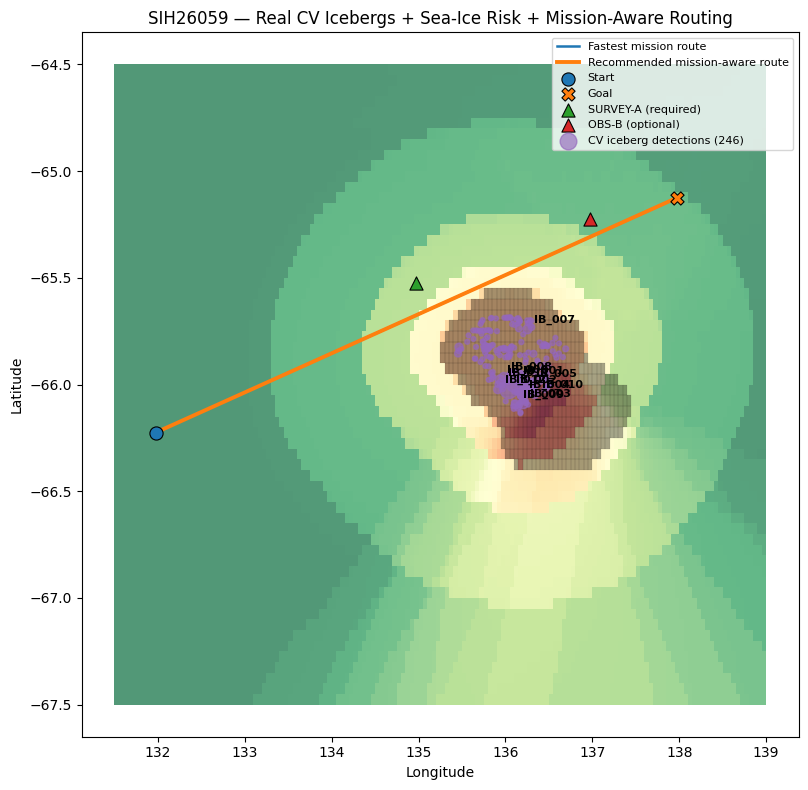

In [11]:
# BASELINE MAP — REAL CV + SEA ICE DATA

fig, ax = plt.subplots(figsize=(12, 8))

grid_wgs84.plot(
    column="total_risk",
    ax=ax,
    cmap="RdYlGn_r",
    legend=False,
    alpha=0.68
)

no_go_gdf = grid_wgs84[
    grid_wgs84["no_go"]
]

if len(no_go_gdf):
    no_go_gdf.plot(
        ax=ax,
        color="black",
        alpha=0.35,
        edgecolor="black",
        linewidth=0.15,
        label="NO-GO"
    )

draw_route(
    ax,
    fastest,
    "Fastest mission route",
    linewidth=1.8
)

draw_route(
    ax,
    recommended,
    "Recommended mission-aware route",
    linewidth=2.8
)

draw_mission_markers(ax)
draw_iceberg_markers(ax)

ax.set_title(
    "SIH26059 — Real CV Icebergs + Sea-Ice Risk + Mission-Aware Routing"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(
    loc="best",
    fontsize=8
)

plt.tight_layout()
plt.show()


In [12]:
# ADAPTIVE REPLANNING — REAL PERSON 3 UPDATE
#
# Baseline:
#   current CV detections + real sea-ice product
#
# Update:
#   add a real 48h Person 3 prediction record.
#
# We deliberately do not perturb or invent a trajectory.
# The update comes directly from the supplied Person 3 output.

# Find spatially relevant predictions.
regional_trajectory = trajectories[
    trajectories["predicted_latitude"].between(-68, -64)
    & trajectories["predicted_longitude"].between(132, 140)
].copy()

# The newest spatially relevant prediction in the supplied file.
latest_regional_time = regional_trajectory[
    "prediction_time"
].max()

latest_regional = regional_trajectory[
    regional_trajectory["prediction_time"]
    == latest_regional_time
].copy()

# Prefer a real 48h prediction because the handoff says
# 24h and 48h have trained-model uncertainty available.
incoming_candidates = latest_regional[
    (latest_regional["horizon_hours"] == 48)
    & latest_regional["uncertainty_km"].notna()
].copy()

if incoming_candidates.empty:
    raise ValueError(
        "No spatially relevant 48h Person 3 prediction "
        "with uncertainty was found in the supplied file."
    )

# Use all matching incoming records for this spatial snapshot.
incoming_update = incoming_candidates.copy()

print("Incoming Person 3 update:")
print(
    incoming_update[
        [
            "iceberg_id",
            "prediction_time",
            "horizon_hours",
            "predicted_latitude",
            "predicted_longitude",
            "uncertainty_km",
        ]
    ].to_string(index=False)
)

print(
    "\nNOTE: This is a real supplied trajectory record, "
    "not a synthetic displacement."
)

# -------------------------
# Recalculate after update
# -------------------------
updated_grid = compute_risk_layers(
    incoming_update
)

before_plan = recommended_plan
before_route = recommended

set_active_grid(updated_grid)

after_plan = plan_mission(
    include_optional=True,
    risk_weight=CONFIG["route_risk_weight"]
)

after_route = (
    after_plan["route"]
    if after_plan
    else None
)

print("\nADAPTIVE REPLANNING RESULT")
print("---------------------------")

# Evaluate the old route against the OLD risk surface.
set_active_grid(baseline_grid)
before_metrics = route_metrics(before_route)
before_safety = validate_route(before_route)
before_mission = mission_evaluation(before_plan)

print("Before:")
print(before_metrics)
print("Before safety:")
print(before_safety)
print("Before mission:")
print(before_mission)

# Evaluate the new route against the UPDATED risk surface.
set_active_grid(updated_grid)
after_metrics = route_metrics(after_route)
after_safety = validate_route(after_route)
after_mission = mission_evaluation(after_plan)

print("\nAfter:")
print(after_metrics)
print("After safety:")
print(after_safety)
print("After mission:")
print(after_mission)

route_changed = before_route != after_route

print(
    "\nREPLAN:",
    route_changed
)

if route_changed:
    print(
        "Adaptive replanning triggered: "
        "the incoming real trajectory prediction changed "
        "the risk landscape and produced a different mission route."
    )
else:
    print(
        "The existing mission route remained feasible under "
        "the incoming trajectory prediction."
    )


Incoming Person 3 update:
iceberg_id prediction_time  horizon_hours  predicted_latitude  predicted_longitude  uncertainty_km
       c32      2023-03-07             48          -66.066635           132.760483       26.474464

NOTE: This is a real supplied trajectory record, not a synthetic displacement.



ADAPTIVE REPLANNING RESULT
---------------------------
Before:
{'distance_km': 504.19, 'eta_hours': 22.69, 'average_risk': 0.035, 'max_risk': 0.148, 'cells': 124}
Before safety:
{'valid': True, 'reason': 'Route passes hard safety constraints', 'no_go_crossings': [], 'elevated_risk_cells': [], 'unsafe_display_segments': [], 'max_route_risk': 0.14825232792383797, 'average_route_risk': 0.035149534827692834}
Before mission:
{'feasible': True, 'reason': 'Mission satisfies safety, science, ETA and distance constraints', 'distance_km': 504.19, 'travel_eta_hours': 22.69, 'service_hours': 6.0, 'mission_eta_hours': 28.69, 'distance_budget_km': 1000.0, 'max_eta_hours': 60.0, 'science_stops': ['SURVEY-A', 'OBS-B'], 'missing_required_waypoints': [], 'route_safe': True, 'no_go_crossings': 0}

After:
{'distance_km': 537.29, 'eta_hours': 24.18, 'average_risk': 0.062, 'max_risk': 0.311, 'cells': 137}
After safety:
{'valid': True, 'reason': 'Route passes hard safety constraints', 'no_go_crossings': [],

/tmp/ipykernel_1398/1268509625.py:63: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(


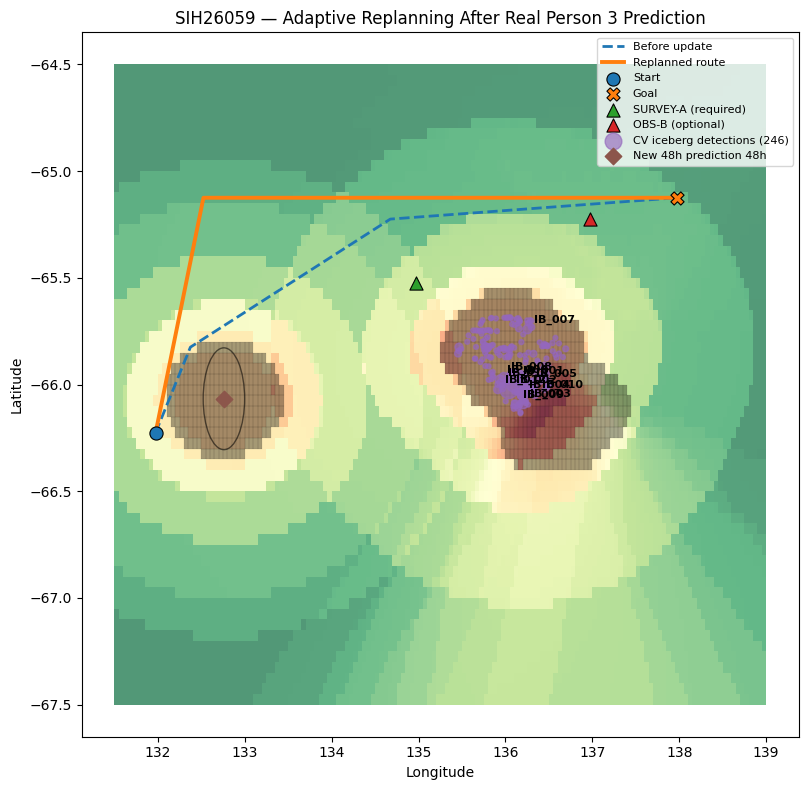

In [13]:
# ADAPTIVE MAP — REAL TRAJECTORY UPDATE

fig, ax = plt.subplots(figsize=(12, 8))

grid_wgs84_updated = (
    grid_projected
    .to_crs("EPSG:4326")
    .reset_index(drop=True)
)

grid_wgs84_updated.plot(
    column="total_risk",
    ax=ax,
    cmap="RdYlGn_r",
    legend=False,
    alpha=0.68
)

updated_no_go = grid_wgs84_updated[
    grid_wgs84_updated["no_go"]
]

if len(updated_no_go):
    updated_no_go.plot(
        ax=ax,
        color="black",
        alpha=0.35,
        edgecolor="black",
        linewidth=0.15,
        label="NO-GO"
    )

# Recompute baseline route display while baseline grid is active
# only for coordinates; the route cells themselves remain valid.
draw_route(
    ax,
    before_route,
    "Before update",
    linewidth=2.0,
    linestyle="--"
)

draw_route(
    ax,
    after_route,
    "Replanned route",
    linewidth=2.8
)

draw_mission_markers(ax)
draw_iceberg_markers(ax)
draw_trajectory_markers(
    ax,
    incoming_update,
    label_prefix="New 48h prediction"
)

ax.set_title(
    "SIH26059 — Adaptive Replanning After Real Person 3 Prediction"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(
    loc="best",
    fontsize=8
)

plt.tight_layout()
plt.show()


In [14]:
# FINAL ROUTE COMPARISON + USP EVIDENCE

# Metrics and safety objects were evaluated against their
# corresponding baseline/updated risk surfaces in the adaptive cell.
set_active_grid(updated_grid)

comparison = pd.DataFrame([
    {
        "stage": "Before trajectory update",
        **before_metrics,
        "route_safe": before_safety["valid"],
        "mission_feasible": before_mission["feasible"],
    },
    {
        "stage": "After trajectory update",
        **after_metrics,
        "route_safe": after_safety["valid"],
        "mission_feasible": after_mission["feasible"],
    },
])

print(comparison.to_string(index=False))

print("\nUSP 1 — Mission-Aware Navigation")
print(
    "Science stops selected:",
    after_mission["science_stops"]
)
print(
    "Required waypoint missing:",
    after_mission["missing_required_waypoints"]
)
print(
    "Mission ETA:",
    after_mission["mission_eta_hours"],
    "hours / limit",
    after_mission["max_eta_hours"]
)
print(
    "Distance:",
    round(after_mission["distance_km"], 2),
    "km / budget",
    after_mission["distance_budget_km"]
)

print("\nUSP 2 — Self-Updating / Continuous Replanning")
print(
    "Incoming real prediction:",
    incoming_update["iceberg_id"].tolist()
)
print(
    "Route changed:",
    before_route != after_route
)
print(
    "New route safety valid:",
    after_safety["valid"]
)

print("\nCOMBINED USP")
print(
    "Adaptive Mission-Aware Navigation = "
    "real environmental update → risk recalculation → "
    "complete mission re-evaluation → automatic safe replanning."
)


                   stage  distance_km  eta_hours  average_risk  max_risk  cells  route_safe  mission_feasible
Before trajectory update       504.19      22.69         0.035     0.148    124        True              True
 After trajectory update       537.29      24.18         0.062     0.311    137        True              True

USP 1 — Mission-Aware Navigation
Science stops selected: ['SURVEY-A', 'OBS-B']
Required waypoint missing: []
Mission ETA: 30.18 hours / limit 60.0
Distance: 537.29 km / budget 1000.0

USP 2 — Self-Updating / Continuous Replanning
Incoming real prediction: ['c32']
Route changed: True
New route safety valid: True

COMBINED USP
Adaptive Mission-Aware Navigation = real environmental update → risk recalculation → complete mission re-evaluation → automatic safe replanning.


In [15]:
# EXPORTS

export_grid = grid_projected.to_crs("EPSG:4326").copy()

export_grid[
    [
        "cell_id",
        "row",
        "col",
        "center_lat",
        "center_lon",
        "iceberg_risk",
        "trajectory_risk",
        "sea_ice_risk",
        "uncertainty_risk",
        "quality_risk",
        "total_risk",
        "no_go",
    ]
].to_csv(
    "risk_grid_real_data.csv",
    index=False
)

icebergs.to_csv(
    "cv_iceberg_detections_used.csv",
    index=False
)

incoming_update.to_csv(
    "trajectory_update_used.csv",
    index=False
)

summary = {
    "cv_detections": int(len(icebergs)),
    "trajectory_predictions_available": int(len(trajectories)),
    "trajectory_uncertainty_available": int(
        trajectories["uncertainty_km"].notna().sum()
    ),
    "sea_ice_observations": int(len(sea_ice)),
    "before": before_metrics,
    "after": after_metrics,
    "before_route_safe": bool(before_safety["valid"]),
    "after_route_safe": bool(after_safety["valid"]),
    "before_mission_feasible": bool(before_mission["feasible"]),
    "after_mission_feasible": bool(after_mission["feasible"]),
    "route_changed": bool(before_route != after_route),
    "trajectory_update_ids": incoming_update["iceberg_id"].tolist(),
    "trajectory_update_time": str(
        incoming_update["prediction_time"].iloc[0]
    ),
    "trajectory_update_horizon_hours": int(
        incoming_update["horizon_hours"].iloc[0]
    ),
}

with open(
    "adaptive_mission_results_real_data.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=2
    )

print("Exports created:")
print("- risk_grid_real_data.csv")
print("- cv_iceberg_detections_used.csv")
print("- trajectory_update_used.csv")
print("- adaptive_mission_results_real_data.json")


Exports created:
- risk_grid_real_data.csv
- cv_iceberg_detections_used.csv
- trajectory_update_used.csv
- adaptive_mission_results_real_data.json


## Final integration summary

### Person 2 → Risk
The notebook consumes the actual CV detections with:
- iceberg ID
- geolocation
- area
- confidence
- timestamp

Confidence is propagated into the safety margin, so lower-confidence detections are treated more conservatively.

### Person 3 → Risk
The notebook consumes the supplied prediction contract:
- `iceberg_id`
- `prediction_time`
- `horizon_hours`
- `predicted_latitude`
- `predicted_longitude`
- `uncertainty_km`

6h/12h rows remain supported, while missing uncertainty is **not** converted to zero.

### Person 5 → Risk
The supplied sea-ice concentration product is used instead of the old hand-entered dummy observations.

### Mission-Aware USP
The planner considers:
- required scientific waypoints
- optional scientific waypoints
- waypoint priority
- service time
- route risk
- distance/fuel-equivalent budget
- mission ETA
- hard NO-GO constraints

### Adaptive USP
The notebook then takes a **real trajectory prediction from Person 3**, recomputes the risk surface, regenerates the complete scientific mission route, validates it, and reports whether the route changed.

This is the evidence chain to show during the SIH demo:

**CV detection → trajectory prediction → risk surface → mission-aware routing → new prediction → automatic replanning.**
